In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")


In [6]:
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [ ]:
#Price coefficient
b_price = model.coef_[X.columns.get_loc("avg_price")]
b_price

np.float64(-0.03766765298429363)

In [10]:
#set up

share_col = "brand_share"

df["demand_slope"] = b_price * df[share_col] * (1 - df[share_col])

df["unit_cost"] = df["avg_price"] + df[share_col] / df["demand_slope"]

df["markup"] = df["avg_price"] - df["unit_cost"]

df["average_profit"] = df[share_col] * df["markup"]

In [11]:
df[["brand", "year", "avg_price", share_col, "demand_slope", "unit_cost", "markup", "average_profit"]].head()

,brand,year,avg_price,brand_share,demand_slope,unit_cost,markup,average_profit
0,chefman,2019,72.963695,0.076015,-0.002646,44.231656,28.732039,2.184062
1,cosori,2019,159.990000,0.000730,-0.000027,133.422638,26.567362,0.019385
2,cuisinart,2019,229.465274,0.107190,-0.003605,199.729962,29.735313,3.187335
3,dash,2019,55.176333,0.199721,-0.006021,22.002913,33.173420,6.625442
4,gowise usa,2019,83.575551,0.292186,-0.007790,46.068541,37.507010,10.959033


In [17]:
# 1. What are the average unit costs and markups for each brand over the years?
print(df.groupby('brand')[['unit_cost', 'markup']].mean().round(2))

             unit_cost  markup
brand                         
chefman          61.57   29.37
cosori           86.28   27.98
cuisinart       194.90   29.05
dash             27.94   29.54
gowise usa       56.30   31.15
instant_pot      71.90   32.56
ninja           112.49   32.85
nuwave          109.05   27.97
oster           161.80   27.23
ultrean          48.79   29.33


In [22]:
# 2. Are any inferred unit costs negative? If so, what might that mean?
neg = df[df['unit_cost'] < 0]
if len(neg):
    print(f"{len(neg)} negative observations:")
    print(neg[['brand', 'year', 'unit_cost']])
else:
    print("None, all unit costs positive. Model looks well-specified.")

None, all unit costs positive. Model looks well-specified.


In [24]:
#3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
q3 = df.groupby('brand').agg(
    avg_unit_cost=('unit_cost', 'mean'),
    avg_rating=('avg_rating', 'mean')
).sort_values('avg_unit_cost', ascending=False)
print(q3.round(3))

             avg_unit_cost  avg_rating
brand                                 
cuisinart          194.896       4.439
oster              161.805       4.389
ninja              112.488       4.742
nuwave             109.054       4.390
cosori              86.283       4.656
instant_pot         71.903       4.559
chefman             61.569       4.428
gowise usa          56.301       4.577
ultrean             48.786       4.673
dash                27.937       4.476


Highest unit costs: Cuisinart ($194.90) and Oster ($161.81) by a wide margin, followed by Ninja and Nuwave. Dash is cheapest at $27.94.

In [26]:
print(q3.corr().round(3))

               avg_unit_cost  avg_rating
avg_unit_cost          1.000      -0.332
avg_rating            -0.332       1.000


Comparing average unit cost & average rating : The correlation is −0.332, meaning there's a weak negative relationship. higher unit cost brands actually tend to have slightly lower ratings.

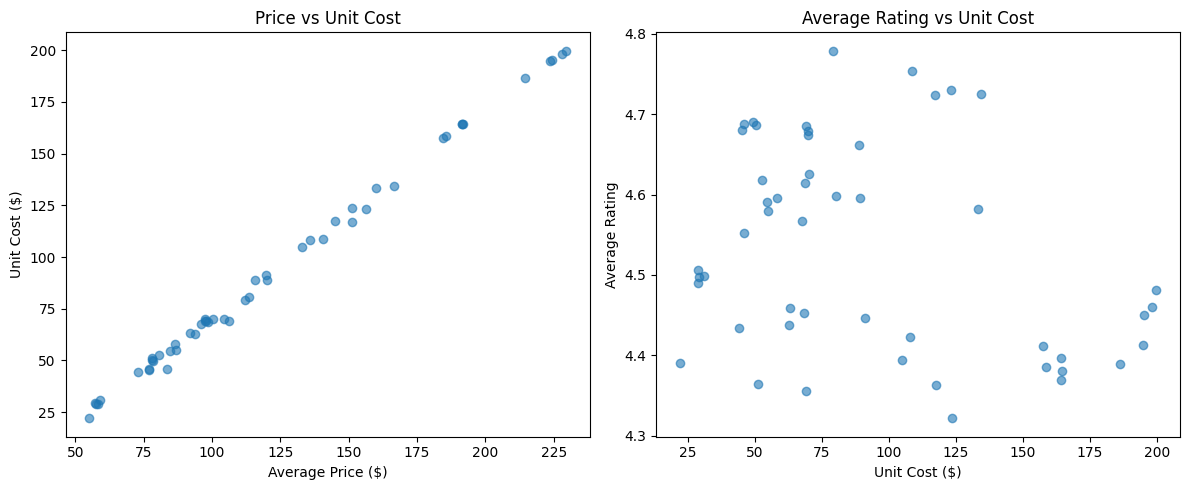

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter 1: price vs unit cost
axes[0].scatter(df['avg_price'], df['unit_cost'], alpha=0.6)
axes[0].set_xlabel('Average Price ($)')
axes[0].set_ylabel('Unit Cost ($)')
axes[0].set_title('Price vs Unit Cost')

# Scatter 2: avg rating vs unit cost
axes[1].scatter(df['unit_cost'], df['avg_rating'], alpha=0.6)
axes[1].set_xlabel('Unit Cost ($)')
axes[1].set_ylabel('Average Rating')
axes[1].set_title('Average Rating vs Unit Cost')

plt.tight_layout()
plt.show()

For Price vs Unit Cost, there is a very tight positive relationship price and unit cost move almost perfectly together. This makes sense mechanically since unit cost is derived from price via the first-order condition. For, Average Rating vs Unit Cost, there is no clear pattern, the cloud is scattered with no upward trend. Thus, more expensive products do not have higher consumer satisfaction. The correlation is −0.332, and the scatter plot confirms no positive relationship

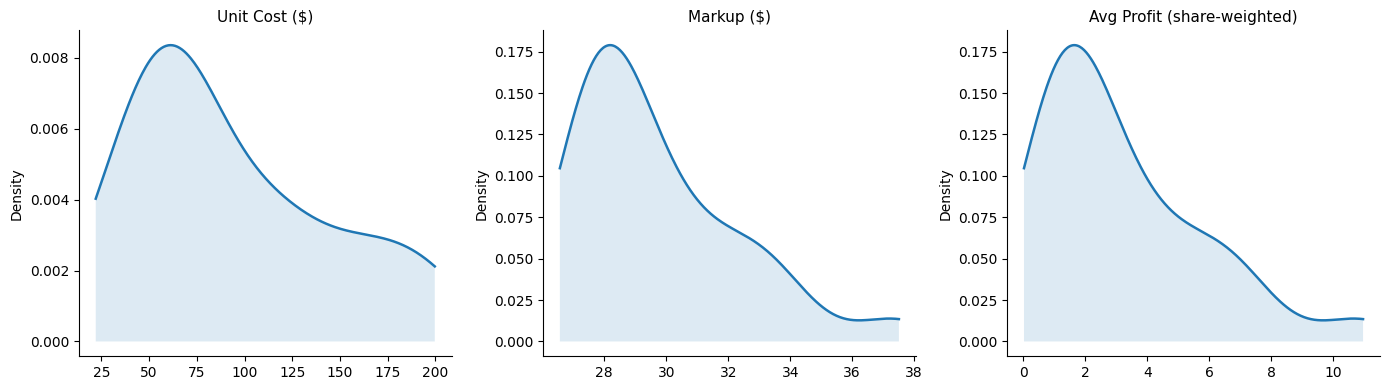

In [ ]:
#4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes,
    ['unit_cost', 'markup', 'average_profit'],
    ['Unit Cost ($)', 'Markup ($)', 'Avg Profit (share-weighted)']):
    data = df[col].dropna()
    kde  = gaussian_kde(data, bw_method='scott')
    xs   = np.linspace(data.min(), data.max(), 300)
    ax.plot(xs, kde(xs), lw=1.8)
    ax.fill_between(xs, kde(xs), alpha=0.15)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Density')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

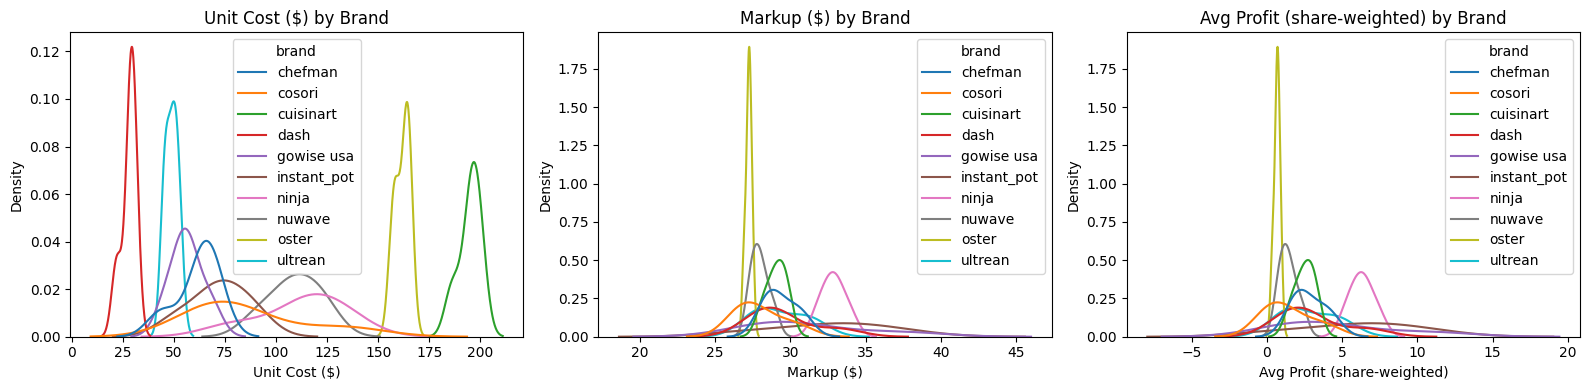

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label in zip(
    axes,
    ['unit_cost', 'markup', 'average_profit'],
    ['Unit Cost ($)', 'Markup ($)', 'Avg Profit (share-weighted)']
):
    sns.kdeplot(
        data=df,
        x=col,
        hue='brand',
        common_norm=False,
        ax=ax
    )
    ax.set_title(label + ' by Brand')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

In [ ]:
#5 Which brands have the highest share-weighted average profit?
print(df.groupby('brand')['average_profit'].mean()
        .sort_values(ascending=False).round(4))

Object `profit` not found.
brand
ninja          6.3061
instant_pot    6.0103
gowise usa     4.6058
dash           2.9944
chefman        2.8210
ultrean        2.7809
cuisinart      2.5030
cosori         1.4367
nuwave         1.4229
oster          0.6783
Name: average_profit, dtype: float64


The brands with the highest share-weighted average profit are:
ninja (6.3061), followed by instant_pot (6.0103) then gowise usa (4.6058).